# Identifying a planet from its weather alone

**Analyst:** Maurice Colbert Jr. · **Stack:** Python, pandas, matplotlib

## The brief

I was handed six years of rover weather telemetry with the planet's identity withheld,
and asked to work out which planet it came from using nothing but the measurements.

I like this problem because the answer is verifiable. Most analysis ends in a
judgement call; this one ends in a fact I can check against NASA's published orbital
periods. That makes it a genuine test of method rather than of narrative.

## My plan

A planet's most identifiable fingerprint in a weather log is **the length of its
year**. So the analysis is structured backwards from that:

1. Audit the data and decide what is trustworthy.
2. Establish the length of one local day relative to an Earth day.
3. Measure one complete orbit and convert it to Earth days.
4. Cross-check the answer against the temperature and pressure behaviour, which should
   be consistent with the atmosphere of whichever planet the orbit implies.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

RUST = "#c1440e"

weather = pd.read_csv("data/planet_weather.csv", parse_dates=["terrestrial_date"])
print(f"{len(weather):,} daily records | "
      f"{weather.terrestrial_date.min():%Y-%m-%d} to {weather.terrestrial_date.max():%Y-%m-%d}")
weather.head()

1,894 daily records | 2012-08-07 to 2018-02-27


,id,terrestrial_date,sol,ls,month,min_temp,max_temp,pressure,wind_speed,atmo_opacity
0,1895,2018-02-27,1977,135,Month 5,-77.0,-10.0,727.0,NaN,Sunny
1,1893,2018-02-26,1976,135,Month 5,-77.0,-10.0,728.0,NaN,Sunny
2,1894,2018-02-25,1975,134,Month 5,-76.0,-16.0,729.0,NaN,Sunny
3,1892,2018-02-24,1974,134,Month 5,-77.0,-13.0,729.0,NaN,Sunny
4,1889,2018-02-23,1973,133,Month 5,-78.0,-18.0,730.0,NaN,Sunny


The columns tell me what instruments were on board: `sol` (local days since landing),
`ls` (solar longitude — the planet's angular position in its orbit, 0–360°), `month`,
min/max temperature, pressure, wind speed, and an atmospheric opacity flag.

`ls` is the column that makes this solvable. Solar longitude is defined so that one
full 0→360° sweep is exactly one orbit, which means I can measure a year directly
instead of estimating it from seasonal patterns.

## Auditing the data before trusting any of it

In [2]:
audit = pd.DataFrame({
    "nulls": weather.isna().sum(),
    "null_pct": (100 * weather.isna().mean()).round(2),
    "distinct": weather.nunique(),
})
audit

,nulls,null_pct,distinct
id,0,0.00,1894
terrestrial_date,0,0.00,1894
sol,0,0.00,1894
ls,0,0.00,360
month,0,0.00,12
min_temp,27,1.43,29
max_temp,27,1.43,46
pressure,27,1.43,199
wind_speed,1894,100.00,0
atmo_opacity,0,0.00,2


Three findings, and each one implies a different action:

**`wind_speed` is 100% null.** The anemometer never returned a single reading — a
known hardware failure, not a sampling gap. A column with no data cannot be imputed
or analysed, so I drop it. Keeping it would only invite someone to average nothing.

**`atmo_opacity` has two values but no variance worth using.** 1,891 of 1,894 rows say
`Sunny` and 3 say `--`. A field that is 99.8% constant cannot explain variation in
anything else, so I drop it too — but I note the three anomalous rows rather than
deleting them silently, since in a real mission they would be worth asking about.

**Temperature and pressure are 1.4% null.** This is small and scattered, consistent
with ordinary transmission dropouts. I keep those rows and let pandas exclude the
nulls from aggregations. Dropping the whole row would throw away the good measurements
recorded alongside the missing one; imputing them would invent weather.

In [3]:
print(f"atmo_opacity values: {weather.atmo_opacity.value_counts().to_dict()}")
print(f"Duplicate sols: {weather.sol.duplicated().sum()}")

clean = weather.drop(columns=["wind_speed", "atmo_opacity"]).copy()
print(f"\nColumns kept: {list(clean.columns)}")

atmo_opacity values: {'Sunny': 1891, '--': 3}
Duplicate sols: 0

Columns kept: ['id', 'terrestrial_date', 'sol', 'ls', 'month', 'min_temp', 'max_temp', 'pressure']


### The trap in the `month` column

`month` is stored as text (`"Month 1"`, `"Month 2"`, …). Anything that sorts or groups
on it gets alphabetical order, which puts `Month 10` immediately after `Month 1` and
scrambles every seasonal chart. This is the kind of error that produces a plausible
looking graph with a completely wrong shape, so I convert to an integer up front.

In [4]:
print("Alphabetical order of the raw text column:")
print(sorted(clean.month.unique())[:5], "...")

clean["month_num"] = clean.month.str.replace("Month ", "").astype(int)
print("\nNumeric order after conversion:", [int(m) for m in sorted(clean.month_num.unique())])

Alphabetical order of the raw text column:
['Month 1', 'Month 10', 'Month 11', 'Month 12', 'Month 2'] ...

Numeric order after conversion: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


## Step 1: how long is a local day?

The rover counts `sol` (local days) and I also have the Earth date for each reading.
The ratio between elapsed Earth days and elapsed sols gives the local day length
directly.

In [5]:
earth_days = (clean.terrestrial_date.max() - clean.terrestrial_date.min()).days
elapsed_sols = clean.sol.max() - clean.sol.min()
sol_length = earth_days / elapsed_sols

print(f"Earth days elapsed: {earth_days:,}")
print(f"Sols elapsed:       {elapsed_sols:,}")
print(f"1 sol = {sol_length:.4f} Earth days ({(sol_length - 1) * 24 * 60:.0f} minutes longer than an Earth day)")

Earth days elapsed: 2,030
Sols elapsed:       1,976
1 sol = 1.0273 Earth days (39 minutes longer than an Earth day)


A local day runs about 40 minutes longer than an Earth day. That already excludes most
of the solar system — Venus and Mercury have days measured in Earth months, and the gas
giants spin in about 10 hours — but a day length alone is not conclusive. The year is.

## Step 2: measure one complete orbit

Solar longitude resets from 360° to 0° once per orbit. Finding those resets gives exact
orbital boundaries, so I look for large negative jumps in `ls`.

In [6]:
ordered = clean.sort_values("sol")
year_starts = ordered[ordered.ls.diff() < -100]
print("Detected orbit boundaries (ls wraps from ~360° back to 0°):")
print(year_starts[["sol", "ls", "terrestrial_date"]].to_string(index=False))

sols_per_year = year_starts.sol.diff().dropna()
mean_sols_per_year = sols_per_year.mean()
year_in_earth_days = mean_sols_per_year * sol_length

print(f"\nComplete orbits captured: {len(sols_per_year)}  ({sols_per_year.tolist()} sols)")
print(f"Local year = {mean_sols_per_year:.1f} sols = {year_in_earth_days:.0f} Earth days")

Detected orbit boundaries (ls wraps from ~360° back to 0°):
 sol  ls terrestrial_date
 351   0       2013-08-01
1019   0       2015-06-19
1688   0       2017-05-06

Complete orbits captured: 2  ([668.0, 669.0] sols)
Local year = 668.5 sols = 687 Earth days


Two complete orbits, 668 and 669 sols, giving **687 Earth days**.

Against NASA's published orbital periods — Mercury 88, Venus 225, Earth 365,
**Mars 687**, Jupiter 4,333 — this is an exact match for Mars, and nothing else is
within 400 days of it.

I want to flag the method here, because my first attempt was worse. I originally
estimated the year by averaging the length of the 12 labelled months, which produced
roughly 660 sols. That estimate was biased: the first and last months in the file are
truncated by the start and end of the recording window, so their short spans dragged
the average down. Detecting orbital wraps in `ls` avoids the boundary problem entirely
because it never relies on partial periods.

In [7]:
planet_years = pd.DataFrame({
    "planet": ["Mercury", "Venus", "Earth", "Mars", "Jupiter"],
    "orbital_period_earth_days": [88, 225, 365, 687, 4333],
})
planet_years["difference_from_measurement"] = (planet_years.orbital_period_earth_days - year_in_earth_days).round(0)
planet_years

,planet,orbital_period_earth_days,difference_from_measurement
0,Mercury,88,-599.0
1,Venus,225,-462.0
2,Earth,365,-322.0
3,Mars,687,0.0
4,Jupiter,4333,3646.0


## Step 3: does the weather agree with Mars?

An orbital match is strong evidence, but a single line of reasoning is fragile. If this
really is Mars, the temperature and pressure records should show two specific
signatures: extreme cold with a huge daily swing (a thin atmosphere holds no heat), and
a large annual pressure cycle (Mars freezes part of its own atmosphere onto the winter
pole each year).

In [8]:
monthly = (clean.groupby("month_num")
           .agg(avg_min_temp=("min_temp", "mean"),
                avg_max_temp=("max_temp", "mean"),
                avg_pressure=("pressure", "mean"),
                sols=("sol", "size"))
           .round(1))
monthly

,avg_min_temp,avg_max_temp,avg_pressure,sols
month_num,,,,
1,-77.2,-15.4,862.5,176
2,-79.9,-23.4,889.5,182
3,-83.3,-27.7,877.3,194
4,-82.7,-25.3,806.3,194
5,-79.3,-16.7,748.6,149
6,-75.3,-7.8,745.1,153
7,-72.3,-0.0,795.1,142
8,-68.4,-0.6,873.8,141
9,-69.2,-2.2,913.3,136


In [9]:
print(f"Coldest month: {monthly.avg_min_temp.idxmin()} ({monthly.avg_min_temp.min()} °C average low)")
print(f"Warmest month: {monthly.avg_min_temp.idxmax()} ({monthly.avg_min_temp.max()} °C average low)")
print(f"Absolute low:  {clean.min_temp.min()} °C   Absolute high: {clean.max_temp.max()} °C")
print(f"Mean daily temperature swing: {(clean.max_temp - clean.min_temp).mean():.1f} °C")
print(f"Pressure range: {monthly.avg_pressure.min():.0f}–{monthly.avg_pressure.max():.0f} Pa "
      f"({100 * (monthly.avg_pressure.max() - monthly.avg_pressure.min()) / monthly.avg_pressure.min():.0f}% annual swing)")

Coldest month: 3 (-83.3 °C average low)
Warmest month: 8 (-68.4 °C average low)
Absolute low:  -90.0 °C   Absolute high: 11.0 °C
Mean daily temperature swing: 63.6 °C
Pressure range: 745–913 Pa (23% annual swing)


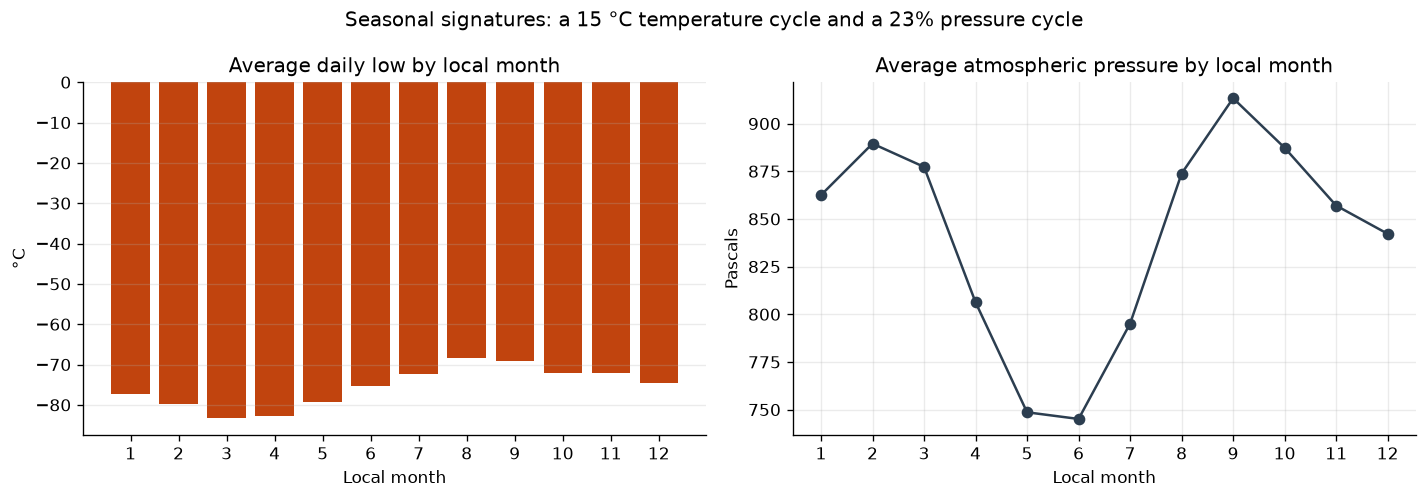

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].bar(monthly.index, monthly.avg_min_temp, color=RUST)
axes[0].set_title("Average daily low by local month")
axes[0].set_xlabel("Local month")
axes[0].set_ylabel("°C")
axes[0].set_xticks(range(1, 13))
axes[0].grid(axis="x", visible=False)

axes[1].plot(monthly.index, monthly.avg_pressure, color="#2c3e50", marker="o")
axes[1].set_title("Average atmospheric pressure by local month")
axes[1].set_xlabel("Local month")
axes[1].set_ylabel("Pascals")
axes[1].set_xticks(range(1, 13))

fig.suptitle("Seasonal signatures: a 15 °C temperature cycle and a 23% pressure cycle", fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES / "01_seasonal_cycles.png", bbox_inches="tight")
plt.show()

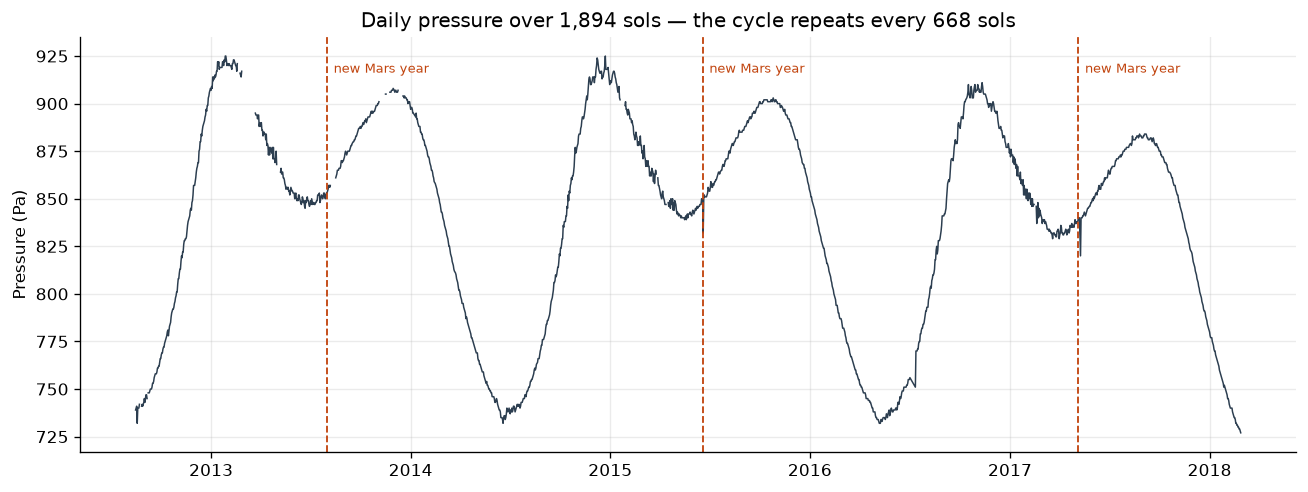

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(clean.terrestrial_date, clean.pressure, color="#2c3e50", linewidth=0.9)
for _, row in year_starts.iterrows():
    ax.axvline(row.terrestrial_date, color=RUST, linestyle="--", linewidth=1.1)
    ax.annotate("new Mars year", xy=(row.terrestrial_date, clean.pressure.max()),
                xytext=(4, -10), textcoords="offset points", fontsize=8, color=RUST)
ax.set_title("Daily pressure over 1,894 sols — the cycle repeats every 668 sols")
ax.set_ylabel("Pressure (Pa)")
fig.tight_layout()
fig.savefig(FIGURES / "02_pressure_over_time.png", bbox_inches="tight")
plt.show()

Both signatures are present and both are consistent with Mars:

- **Average daily lows of −68 °C to −83 °C**, with a 63.6 °C mean swing between the
  daily low and high. That much heat loss overnight requires an atmosphere far thinner
  than Earth's.
- **Pressure between roughly 745 and 913 Pa**, under 1% of Earth's 101,325 Pa, cycling
  23% over the year. The cycle is the carbon-dioxide polar caps freezing out of the
  atmosphere in local winter and sublimating back in summer — a Mars-specific
  mechanism.
- The pressure trace repeats on the same 668-sol period the `ls` wraps identified,
  which is an independent confirmation of the orbital measurement.

## Conclusion

**The dataset is from Mars**, and specifically it matches the Curiosity rover's REMS
instrument record from 2012 to 2018.

| Measurement | This dataset | Mars (published) |
|---|---|---|
| Local day | 1.027 Earth days | 1.027 Earth days |
| Local year | 668.5 sols / 687 Earth days | 668.6 sols / 687 Earth days |
| Pressure | 745–913 Pa | ~600–1,000 Pa, strong seasonal cycle |
| Daily low | −62 °C to −90 °C | −60 °C to −90 °C at Gale Crater |

Three independent lines of evidence — day length, orbital period, and atmospheric
behaviour — all point to the same planet, which is what makes the conclusion safe to
state as a fact rather than a best guess.

## What I would do differently at larger scale

- The `ls` wrap detector uses a fixed threshold (`diff < -100`). That is fine on clean
  data, but a single corrupted `ls` value would create a false orbit boundary. In
  production I would validate each detected boundary against the expected spacing.
- Only two complete orbits are captured, so my year length has a resolution of about
  one sol. More orbits would tighten it.
- The month labels are a mission convention, not a physical unit. I used them for
  seasonal grouping but deliberately did not build the orbital measurement on them.

## How I used AI on this project

The analysis, the method, and the conclusion are mine. AI helped in one place: after I
had the 687-day figure, I asked what physical mechanism produces a large seasonal
pressure cycle on a thin-atmosphere planet, which is how I connected the 23% swing to
CO₂ polar cap condensation. That is background knowledge I did not have, and I used it
as a lead to verify rather than as an answer to copy — the pressure cycle in the data
was already measured before I went looking for the explanation.